# 4. safety mechanisms: uncertainty, conformal routing, cross-check, contamination index, decision engine

**what this notebook shows:** the parts that make the sorter *safe*. each part is a small piece of real code you can read and run.

the main idea: the model must know when it is unsure, and a dangerous item (battery, e-waste, medical) must never go to recycling.

In [1]:
# find the project folder, so the notebook works from any place
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
root = Path.cwd()
while not (root / "pyproject.toml").exists():
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root / "src"))
print("project folder:", root)

project folder: C:\Users\91738\edge-waste


In [2]:
# load the saved model outputs and the classifier head (the last small part of the network)
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
from edgewaste import taxonomy as tx
from edgewaste.decision_engine.conformal_routing import HAZ, alpha_vector, calibrate, family_matrix, prediction_sets

val = np.load("runs/analysis/convnext_vit/cache_val.npz", allow_pickle=True)
test = np.load("runs/analysis/convnext_vit/cache_test.npz", allow_pickle=True)
names = list(test["class_names"])
y_test = test["labels"].astype(int)
M = family_matrix(names)                      # 33 x 9 table: which class belongs to which family
fam_true = M[y_test].argmax(1)

ck = torch.load("runs/stage1/best.pt", map_location="cpu", weights_only=False)
p = ck["model_cfg"]["dropout"]
head = nn.Sequential(nn.Dropout(p), nn.Linear(1024, 512), nn.GELU(), nn.Dropout(p), nn.Linear(512, 33))
head.load_state_dict({k[5:]: v for k, v in ck["model_state"].items() if k.startswith("head.")})
head.eval()
print("head loaded; dropout rate:", p)

head loaded; dropout rate: 0.2


## 1. uncertainty with monte carlo dropout

we run the classifier head 25 times with dropout switched **on**. if the 25 answers agree, the model is sure. if they differ, it is unsure. uncertainty `U` is the normalised entropy of the average answer: 0 = sure, 1 = completely unsure.

average uncertainty, right answers: 0.394
average uncertainty, wrong answers: 0.463   (higher is what we want)


AUROC for finding mistakes: mc dropout 0.598  |  plain max probability 0.657


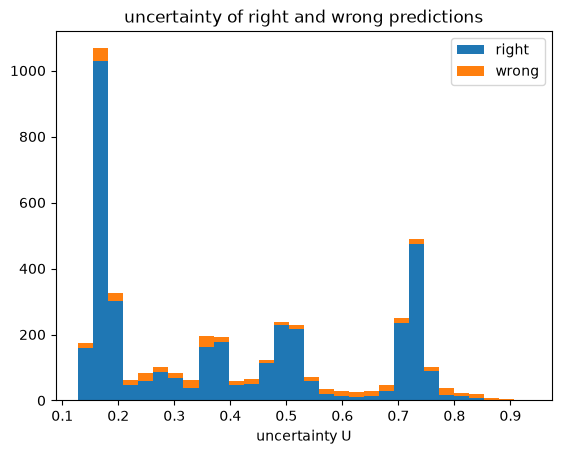

In [3]:
# monte carlo dropout, written out in plain steps
@torch.no_grad()
def mc_uncertainty(emb, passes=25):
    head.train()                                               # dropout on
    probs = torch.stack([torch.softmax(head(emb), 1) for _ in range(passes)]).mean(0)
    head.eval()                                                # dropout off again
    entropy = -(probs * (probs + 1e-12).log()).sum(1)
    return probs, entropy / np.log(probs.shape[1])             # divide by log(33) so U is between 0 and 1

torch.manual_seed(0)
emb_test = torch.from_numpy(test["emb"].astype(np.float32))
_, U = mc_uncertainty(emb_test)
U = U.numpy()
pred = test["logits"].argmax(1)
wrong = pred != y_test
print(f"average uncertainty, right answers: {U[~wrong].mean():.3f}")
print(f"average uncertainty, wrong answers: {U[wrong].mean():.3f}   (higher is what we want)")

from sklearn.metrics import roc_auc_score
msp = torch.softmax(torch.from_numpy(test["logits"]), 1).max(1).values.numpy()
print(f"AUROC for finding mistakes: mc dropout {roc_auc_score(wrong, U):.3f}  |  plain max probability {roc_auc_score(wrong, -msp):.3f}")
plt.hist([U[~wrong], U[wrong]], bins=30, label=["right", "wrong"], stacked=True)
plt.xlabel("uncertainty U"); plt.legend(); plt.title("uncertainty of right and wrong predictions"); plt.show()

## 2. conformal routing: a limit on how often a hazard reaches recycling

steps: (1) add the class probabilities into *family* totals; (2) on labelled calibration data, find for each family a threshold; (3) for a new item, keep every family whose total passes its threshold. this gives a *set* of possible families. if `hazardous` is in the set, the item is never sent to a recycling bin.

In [4]:
# the core of the method: thresholds per family and prediction sets (real project code)
import inspect
from edgewaste.decision_engine import conformal_routing as cr
print(inspect.getsource(cr.conformal_rank))
print(inspect.getsource(cr.calibrate))
print(inspect.getsource(cr.prediction_sets))

def conformal_rank(n: int, alpha: float, delta: float | None = None) -> int | None:
    """1-based rank of the calibration score to use as threshold, or None if
    n is too small to certify the target.

    delta=None: standard split conformal, coverage >= 1-alpha on average over
    calibration draws (a single deployment can land somewhat below it).

    delta given: calibration-conditional (PAC) version. The true coverage of
    the k-th smallest of n scores is Beta(k, n+1-k) distributed, so choosing
    the smallest k whose delta-quantile clears 1-alpha gives coverage >= 1-alpha
    with probability >= 1-delta for THIS calibration set — a per-deployment
    statement rather than an average one."""
    if n == 0:
        return None
    if delta is None:
        k = math.ceil((n + 1) * (1 - alpha))
        return k if k <= n else None
    from scipy.stats import beta
    ks = np.arange(1, n + 1)
    ok = beta.ppf(delta, ks, n + 1 - ks) >= 1 - alpha
    return int(ks[ok][0]) if ok.an

In [5]:
# test it: split the test images in two random halves 100 times. one half calibrates, the other half is scored.
probs = torch.softmax(torch.from_numpy(test["logits"]), 1).numpy().astype(np.float64)
fam_mass = probs @ M
top_fam = M[probs.argmax(1)].argmax(1)
is_haz = fam_true == HAZ
rng = np.random.default_rng(1)

def leakage_and_review(alpha_h, trials=100):
    leaks, reviews, leaks_gate, reviews_gate = [], [], [], []
    for _ in range(trials):
        perm = rng.permutation(len(y_test))
        cal_i, ev = perm[: len(perm) // 2], perm[len(perm) // 2:]
        q = calibrate(fam_mass[cal_i], fam_true[cal_i], alpha_vector(0.10, alpha_h))
        sets = prediction_sets(fam_mass[ev], q)
        single = sets.sum(1) == 1
        auto = single & (U[ev] < np.quantile(U[cal_i], 0.9))            # one family and low uncertainty
        auto_to_recycling = auto & (np.where(single, sets.argmax(1), -1) != HAZ)
        hz = is_haz[ev]
        leaks.append((hz & auto_to_recycling).sum() / hz.sum())
        reviews.append((~auto).mean())
        # baseline: plain max-probability gate with the same review share
        thr = np.quantile(msp[cal_i], np.mean(~auto))
        ok = msp[ev] >= thr
        leaks_gate.append((hz & ok & (top_fam[ev] != HAZ)).sum() / hz.sum())
    return np.mean(leaks) * 100, np.mean(reviews) * 100, np.mean(leaks_gate) * 100

top1_leak = (is_haz & (top_fam != HAZ)).sum() / is_haz.sum() * 100
print(f"top-1 routing with no gate: {top1_leak:.2f}% of hazards reach a recycling bin\n")
print(f"{'alpha_H':>8s} {'conformal leak %':>17s} {'items to review %':>18s} {'max-prob gate leak %':>21s}")
for a in (0.05, 0.02, 0.01):
    l, r, lg = leakage_and_review(a)
    print(f"{a:8.2f} {l:17.2f} {r:18.1f} {lg:21.2f}")

top-1 routing with no gate: 6.50% of hazards reach a recycling bin

 alpha_H  conformal leak %  items to review %  max-prob gate leak %
    0.05              2.63               12.8                  3.28
    0.02              1.47               15.1                  3.17
    0.01              0.75               34.6                  1.63


read the table: the operator picks `alpha_H` (the allowed hazard leakage). the measured leakage stays below it, and a smaller `alpha_H` costs more items sent to a person. the guarantee is for items that look like the calibration items. for very different images the uncertainty gate gives extra protection.

## 3. object-material cross-check that never weakens a hazard

the object detector says *what the object is* (for example a can). a can is not made of plastic, so plastic gets a lower weight. classes in the hazardous family always keep full weight.

In [6]:
# a real example: an aluminium soda can that the classifier first calls a plastic bottle
import inspect
from edgewaste.decision_engine import object_identity_prior as oip
print(inspect.getsource(oip.apply_identity_prior))
can = names.index("aluminum_soda_cans")
idx = [i for i in range(len(y_test)) if y_test[i] == can and pred[i] != can][0]
p0 = torch.from_numpy(probs[idx]).float()
p1 = oip.apply_identity_prior(p0, "Can")
for label, pr in (("before cross-check", p0), ("after cross-check ", p1)):
    top = pr.argsort(descending=True)[:2]
    print(label, "->", ", ".join(f"{names[i]} {pr[i] * 100:.0f}%" for i in top))
print("is 'battery' a consistent reading for a Can?", oip.is_consistent("Can", "battery"), " (hazards are never treated as a contradiction)")

def apply_identity_prior(
    material_probs: torch.Tensor, object_class: str,
    class_names: list[str] | tuple[str, ...] = CLASS_NAMES,
) -> torch.Tensor:
    """Re-weight a material distribution by the object identity, renormalised."""
    weights = prior_vector(object_class, class_names).to(material_probs.device)
    adjusted = material_probs * weights
    total = adjusted.sum()
    if total <= 0:  # degenerate; fall back to the unmodified distribution
        return material_probs
    return adjusted / total

before cross-check -> plastic_water_bottles 69%, aluminum_soda_cans 4%
after cross-check  -> plastic_water_bottles 40%, aluminum_soda_cans 17%
is 'battery' a consistent reading for a Can? True  (hazards are never treated as a contradiction)


## 4. organic contamination index (oci) from two sensors

moisture and gas readings are scaled to 0-1 with fixed anchors, then three small models are fitted: both sensors, moisture only, gas only. if a sensor fails, the matching model is used. the threshold is chosen so that at least 95% of contaminated items are found. **the sensor data here is simulated** because the physical sensors are not built yet.

In [7]:
# fit the three models on simulated calibration data
from edgewaste.contamination.synthetic_calibration_data import generate_synthetic_calibration_data
from edgewaste.contamination.sensor_normalization import normalize_gas, normalize_moisture
from edgewaste.contamination.oci_model import fit_oci_weights, compute_oci, select_threshold

train_df, anchors = generate_synthetic_calibration_data(n_replicates=300, seed=0)
test_df, _ = generate_synthetic_calibration_data(n_replicates=300, seed=1, anchors=anchors)

def features(df):
    fm = np.array([normalize_moisture(m, anchors) for m in df.moisture_raw])
    fg = np.array([normalize_gas(r, anchors) if False else float(np.clip((-np.log(r) - anchors.l_min) / (anchors.l_max - anchors.l_min), 0, 1)) for r in df.rs_over_r0])
    return fm, fg

fm_tr, fg_tr = features(train_df); y_tr = train_df.contaminated.values.astype(int)
fm_te, fg_te = features(test_df);  y_te = test_df.contaminated.values.astype(int)
model, info = fit_oci_weights(fm_tr, fg_tr, y_tr, use_interaction=True)
print("model coefficients:", {k: round(v, 3) for k, v in model.__dict__.items() if k != "operating_threshold"})

def score(fm, fg, use_m=True, use_g=True):
    return np.array([compute_oci(model, a if use_m else None, b if use_g else None) for a, b in zip(fm, fg)])

cases = {"both sensors": (True, True), "moisture only": (True, False), "gas only": (False, True)}
print(f"\n{'case':15s} {'threshold':>9s} {'sensitivity':>12s} {'false positive rate':>20s}")
for name, (um, ug) in cases.items():
    thr = select_threshold(y_tr, score(fm_tr, fg_tr, um, ug), 0.95)["operating_threshold"]
    s = score(fm_te, fg_te, um, ug)
    print(f"{name:15s} {thr:9.3f} {(s[y_te == 1] >= thr).mean() * 100:11.1f}% {(s[y_te == 0] >= thr).mean() * 100:19.1f}%")

model coefficients: {'beta0': -3.336, 'beta1': 5.112, 'beta2': 6.456, 'beta3': 4.116, 'm_only_beta0': -2.855, 'm_only_beta1': 7.395, 'g_only_beta0': -1.462, 'g_only_beta1': 10.14}

case            threshold  sensitivity  false positive rate
both sensors        0.339        94.0%                71.0%
moisture only       0.340        94.1%                80.2%
gas only            0.389        94.2%                78.9%


In [8]:
# what if the gas sensor breaks? compare the dedicated model with "put zero for the missing gas value"
thr_both = select_threshold(y_tr, score(fm_tr, fg_tr), 0.95)["operating_threshold"]
thr_m = select_threshold(y_tr, score(fm_tr, fg_tr, True, False), 0.95)["operating_threshold"]
dedicated = score(fm_te, fg_te, True, False)
default_zero = score(fm_te, np.zeros_like(fg_te))            # wrong way: pretend gas = 0
print(f"gas lost, dedicated moisture model + own threshold : sensitivity {(dedicated[y_te == 1] >= thr_m).mean() * 100:.1f}%")
print(f"gas lost, gas = 0 in the big model + its threshold : sensitivity {(default_zero[y_te == 1] >= thr_both).mean() * 100:.1f}%   (target was 95%)")

gas lost, dedicated moisture model + own threshold : sensitivity 94.1%
gas lost, gas = 0 in the big model + its threshold : sensitivity 40.9%   (target was 95%)


## 5. the decision engine

it combines the item, the uncertainty, the family set and the contamination score and returns one action.

In [9]:
# four example items through the real decision function
from edgewaste.decision_engine.routing_rules import decide
cases = [
    ("plastic_water_bottles", 0.92, 0.17, 0.10, {"plastic"}),
    ("battery", 0.84, 0.30, 0.10, {"hazardous"}),
    ("battery", 0.45, 0.80, 0.10, {"hazardous", "metal"}),
    ("cardboard_boxes", 0.88, 0.20, 0.90, {"cardboard"}),
    ("aluminum_soda_cans", 0.20, 0.81, 0.10, set()),
]
for name, conf, u, oci, fam in cases:
    d = decide(name, conf, u, oci, uncertainty_threshold=0.73, oci_threshold=0.5, family_set=fam)
    print(f"{name:24s} U={u:.2f} OCI={oci:.2f} set={sorted(fam)!s:24s} -> {d.route}")

plastic_water_bottles    U=0.17 OCI=0.10 set=['plastic']              -> plastic
battery                  U=0.30 OCI=0.10 set=['hazardous']            -> hazardous
battery                  U=0.80 OCI=0.10 set=['hazardous', 'metal']   -> manual_review
cardboard_boxes          U=0.20 OCI=0.90 set=['cardboard']            -> contaminated_reject
aluminum_soda_cans       U=0.81 OCI=0.10 set=[]                       -> manual_review
